# A-level languages: Spanish, French and German against GCSE languages

The same question as for English and the sciences, now for modern languages. We model A-level Spanish, French and German value added together against GCSE languages value added (`LANVAMEA_PTQ_EE`, the languages element of the GCSE value-added measure).

The model is the correlated-residuals model from the science notebook:

- a latent school-level **GCSE languages VA**, measured with known error;
- **subject-specific** intercept and slope on that GCSE VA;
- **correlated school residuals** across the three subjects, with an LKJ prior on the correlation matrix.

This dataset is much thinner than the sciences: few schools offer A-level languages, cohorts are tiny, and very few schools have all three subjects. So we check the data carefully first, and decide whether the more complex shared-school-effect model is worth attempting only after seeing these results.

In [1]:
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt

%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.3.1


## Data

We reshape `all-value-add-errors.csv` to long format: one row per school × subject, keeping the published confidence interval and entries. Schools need GCSE languages VA and at least one of the three A-level VA scores. The standard error is `(upper - lower) / (2 * 1.96)`.

First, a check that French, German and Spanish are the right three subjects: the modern-language A-levels ranked by the number of schools that have both the A-level score and GCSE languages VA. (Classical Civilisation also appears in the data but is not a modern language; Polish, Turkish, Latin and the rest each have 16 or fewer schools.)

In [2]:
raw = pd.read_csv("data/all-value-add-errors.csv")

gcse_ok = raw[["LANVAMEA_PTQ_EE", "LANVAMEA_PTQ_EE lower", "LANVAMEA_PTQ_EE upper", "LANVAMEA_PTQ_EE pupils"]].notna().all(axis=1)
candidates = ["Spanish", "French", "German", "Italian", "Latin", "Chinese", "Arabic", "Polish", "Portuguese", "Punjabi",
              "Russian", "Turkish", "Urdu", "Modern Hebrew", "Classical Greek", "Other Classical Languages", "Classical Civilisation"]
rows = []
for name in candidates:
    p = f"A-level {name}"
    ok = raw[[f"{p} VA", f"{p} VA lower", f"{p} VA upper", f"{p} entries"]].notna().all(axis=1)
    rows.append({"subject": name, "schools_with_gcse_languages": int((ok & gcse_ok).sum()),
                 "median_entries": raw.loc[ok & gcse_ok, f"{p} entries"].median()})
ranking = pd.DataFrame(rows).sort_values("schools_with_gcse_languages", ascending=False).head(8).reset_index(drop=True)
ranking

,subject,schools_with_gcse_languages,median_entries
0,Spanish,267,8.0
1,French,205,7.0
2,Classical Civilisation,93,10.0
3,German,52,7.0
4,Polish,16,7.5
5,Turkish,15,8.0
6,Latin,10,8.0
7,Arabic,5,8.0


In [3]:
subjects = ["Spanish", "French", "German"]
school_cols = ["URN", "LANVAMEA_PTQ_EE", "LANVAMEA_PTQ_EE lower", "LANVAMEA_PTQ_EE upper", "LANVAMEA_PTQ_EE pupils"]

schools = (
    raw[school_cols]
    .rename(columns={"LANVAMEA_PTQ_EE": "gcse_va", "LANVAMEA_PTQ_EE lower": "gcse_lower",
                     "LANVAMEA_PTQ_EE upper": "gcse_upper", "LANVAMEA_PTQ_EE pupils": "gcse_pupils"})
    .dropna()
)

frames = []
for subject in subjects:
    prefix = f"A-level {subject}"
    sub = raw[["URN", f"{prefix} VA", f"{prefix} VA lower", f"{prefix} VA upper", f"{prefix} entries"]].dropna()
    sub.columns = ["URN", "alevel_va", "alevel_lower", "alevel_upper", "alevel_entries"]
    sub["subject"] = subject
    frames.append(sub)
long = pd.concat(frames)

Z_95 = 1.96
long["alevel_se"] = (long["alevel_upper"] - long["alevel_lower"]) / (2 * Z_95)
schools["gcse_se"] = (schools["gcse_upper"] - schools["gcse_lower"]) / (2 * Z_95)

long = long.merge(schools[["URN"]], on="URN", how="inner")
schools = schools[schools["URN"].isin(long["URN"])].reset_index(drop=True)

school_idx = pd.Series(np.arange(len(schools)), index=schools["URN"])
long["school_idx"] = long["URN"].map(school_idx).to_numpy()
long["subject_idx"] = long["subject"].map({s: k for k, s in enumerate(subjects)}).to_numpy()
long = long.reset_index(drop=True)

print(f"{len(schools)} schools, {len(long)} school-subject observations")
print("subjects per school:", long.groupby("URN")["subject"].nunique().value_counts().sort_index().to_dict())

presence = long.pivot(index="URN", columns="subject", values="alevel_va")[subjects].notna().astype(int)
overlap = presence.T @ presence
print("\nSchools with each pair of subjects (diagonal = schools with that subject):")
display(overlap)
long.groupby("subject")[["alevel_va", "alevel_se", "alevel_entries"]].agg(["mean", "std", "median"]).round(3)

380 schools, 524 school-subject observations
subjects per school: {1: 252, 2: 112, 3: 16}

Schools with each pair of subjects (diagonal = schools with that subject):


subject,Spanish,French,German
subject,,,
Spanish,267,107,25
French,107,205,28
German,25,28,52


alevel_va               alevel_se               alevel_entries         \
             mean    std median      mean    std median           mean    std   
subject                                                                         
French     -0.029  0.537 -0.020     0.369  0.051  0.388          8.390  3.174   
German     -0.109  0.506 -0.055     0.374  0.041  0.388          7.827  1.968   
Spanish    -0.098  0.566 -0.060     0.369  0.053  0.375          8.985  3.074   

                
        median  
subject         
French     7.0  
German     7.0  
Spanish    8.0

### Checking the confidence-interval formula

DfE's interval is $\pm 1.96\,\sigma_{national}/\sqrt{n}$, so $se\sqrt{n}$ should be constant within each measure.

In [4]:
print((long["alevel_se"] * np.sqrt(long["alevel_entries"])).groupby(long["subject"]).agg(["mean", "std"]).round(3))
print("GCSE languages:", (schools["gcse_se"] * np.sqrt(schools["gcse_pupils"])).agg(["mean", "std"]).round(3).to_dict())

          mean    std
subject              
French   1.030  0.003
German   1.025  0.001
Spanish  1.066  0.003
GCSE languages: {'mean': 1.959, 'std': 0.012}


Each measure has its own near-constant national SD, so the standard errors are pure sampling noise.

## Exploratory look

Left: each subject against GCSE languages VA. Right: raw pairwise correlations between the A-level VA scores, using the schools that have each pair (107 for Spanish-French, 25 for Spanish-German, 28 for French-German).

/tmp/ipykernel_102965/2639947637.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


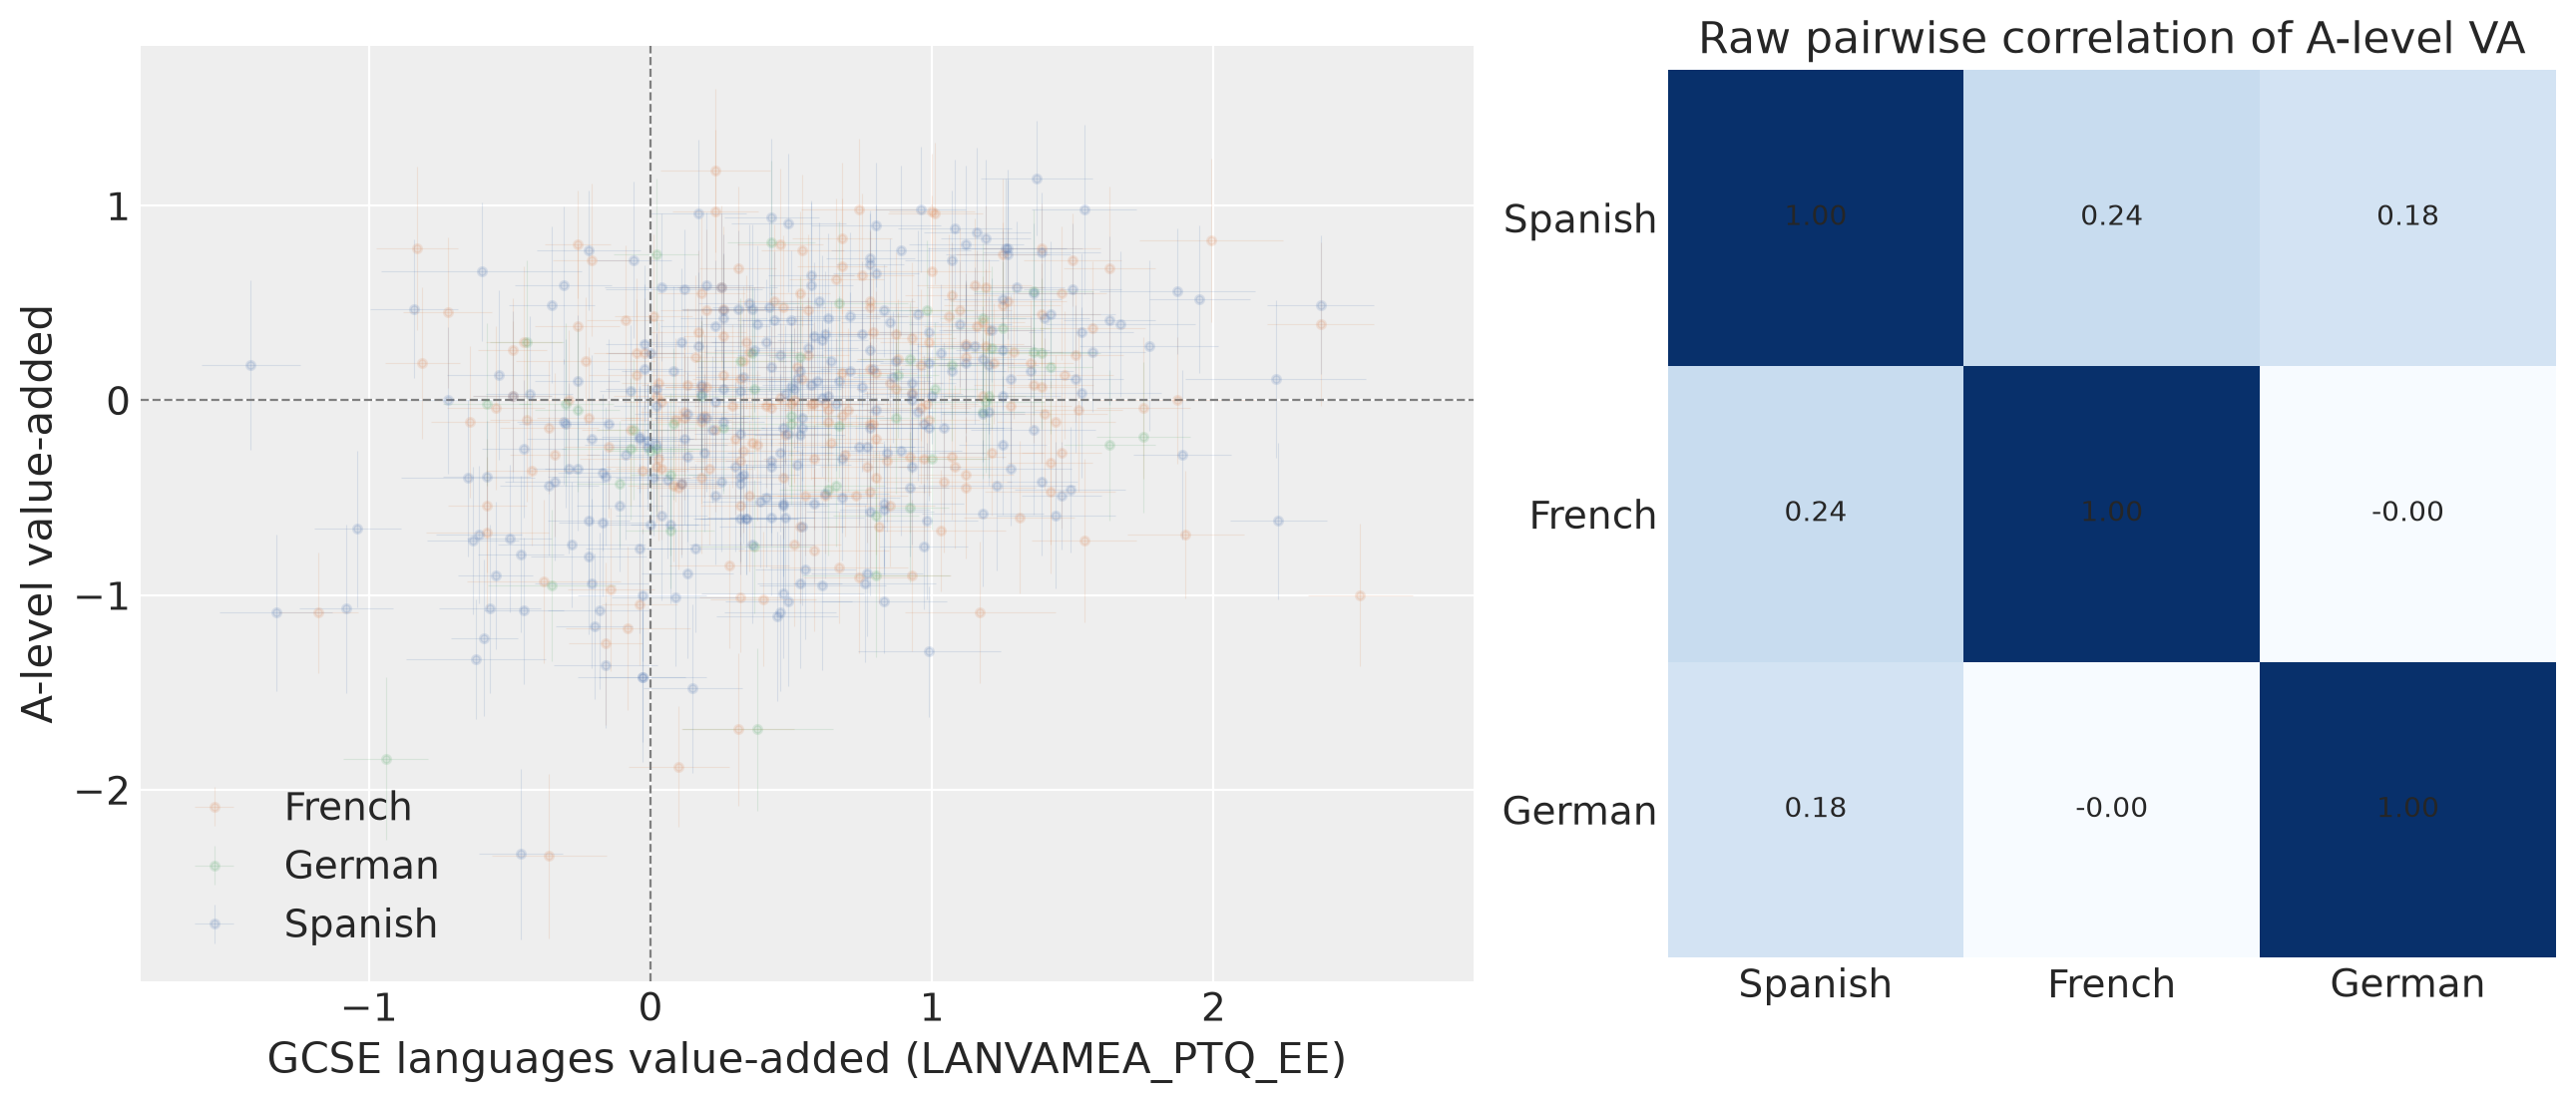

In [5]:
colors = {"Spanish": "#4C72B0", "French": "#DD8452", "German": "#55A868"}
plot_df = long.merge(schools[["URN", "gcse_va", "gcse_se"]], on="URN")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})
for subject, g in plot_df.groupby("subject"):
    axes[0].errorbar(g["gcse_va"], g["alevel_va"], xerr=g["gcse_se"], yerr=g["alevel_se"], fmt="o",
                     color=colors[subject], ecolor=colors[subject], alpha=0.15, markersize=3, elinewidth=0.4, label=subject)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("GCSE languages value-added (LANVAMEA_PTQ_EE)")
axes[0].set_ylabel("A-level value-added")
axes[0].legend()

wide = long.pivot(index="URN", columns="subject", values="alevel_va")[subjects]
raw_corr = wide.corr(min_periods=10)
im = axes[1].imshow(raw_corr, vmin=0, vmax=1, cmap="Blues")
axes[1].set_xticks(range(3), subjects)
axes[1].set_yticks(range(3), subjects)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{raw_corr.iloc[i, j]:.2f}", ha="center", va="center")
axes[1].set_title("Raw pairwise correlation of A-level VA")
axes[1].grid(False)
plt.tight_layout()
plt.show()

These raw correlations are attenuated by sampling noise in each score, which the model handles, and the German pairs rest on very few schools.

## Model

For school $i$ with true GCSE VA $x_i$, and subject $s \in \{\text{Spanish}, \text{French}, \text{German}\}$:

$$
\begin{aligned}
x_i &\sim \text{Normal}(\mu_x, \tau_x), \qquad x_i^{obs} \sim \text{Normal}(x_i, \sigma^x_i) \\
y_{is} &= \alpha_s + \beta_s x_i + \epsilon_{is}, \qquad y_{is}^{obs} \sim \text{Normal}(y_{is}, \sigma^y_{is}) \\
\boldsymbol{\epsilon}_i &\sim \text{MultivariateNormal}(0, \Sigma), \qquad \Sigma = \text{diag}(\tau)\, R\, \text{diag}(\tau), \quad R \sim \text{LKJ}(\eta = 2)
\end{aligned}
$$

$R$ is the $3\times3$ correlation matrix of a school's true subject effects once the GCSE effect is removed. Schools with fewer than three subjects contribute through the marginal distribution of the subjects they have. Each subject's $\alpha_s, \beta_s$ gets its own weakly informative prior. The residuals are non-centered via the Cholesky factor of $\Sigma$.

In [6]:
n_schools = len(schools)
gcse_obs = schools["gcse_va"].to_numpy()
gcse_se = schools["gcse_se"].to_numpy()
y_obs = long["alevel_va"].to_numpy()
y_se = long["alevel_se"].to_numpy()
s_idx = long["school_idx"].to_numpy()
subj_idx = long["subject_idx"].to_numpy()
n_subjects = len(subjects)

with pm.Model(coords={"subject": subjects}) as corr_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")

    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov", n=n_subjects, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0, shape=n_subjects), compute_corr=True
    )
    z = pm.Normal("z", 0, 1, shape=(n_schools, n_subjects))
    eps_all = pt.dot(z, chol.T)
    eps = eps_all[s_idx, subj_idx]

    y_true = alpha[subj_idx] + beta[subj_idx] * x_true[s_idx] + eps

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=y_se, observed=y_obs)

### Prior predictive check

Sampling: [alevel_obs, alpha, beta, chol_cov, gcse_obs, mu_x, tau_x, x_raw, z]


/tmp/ipykernel_102965/3802092383.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


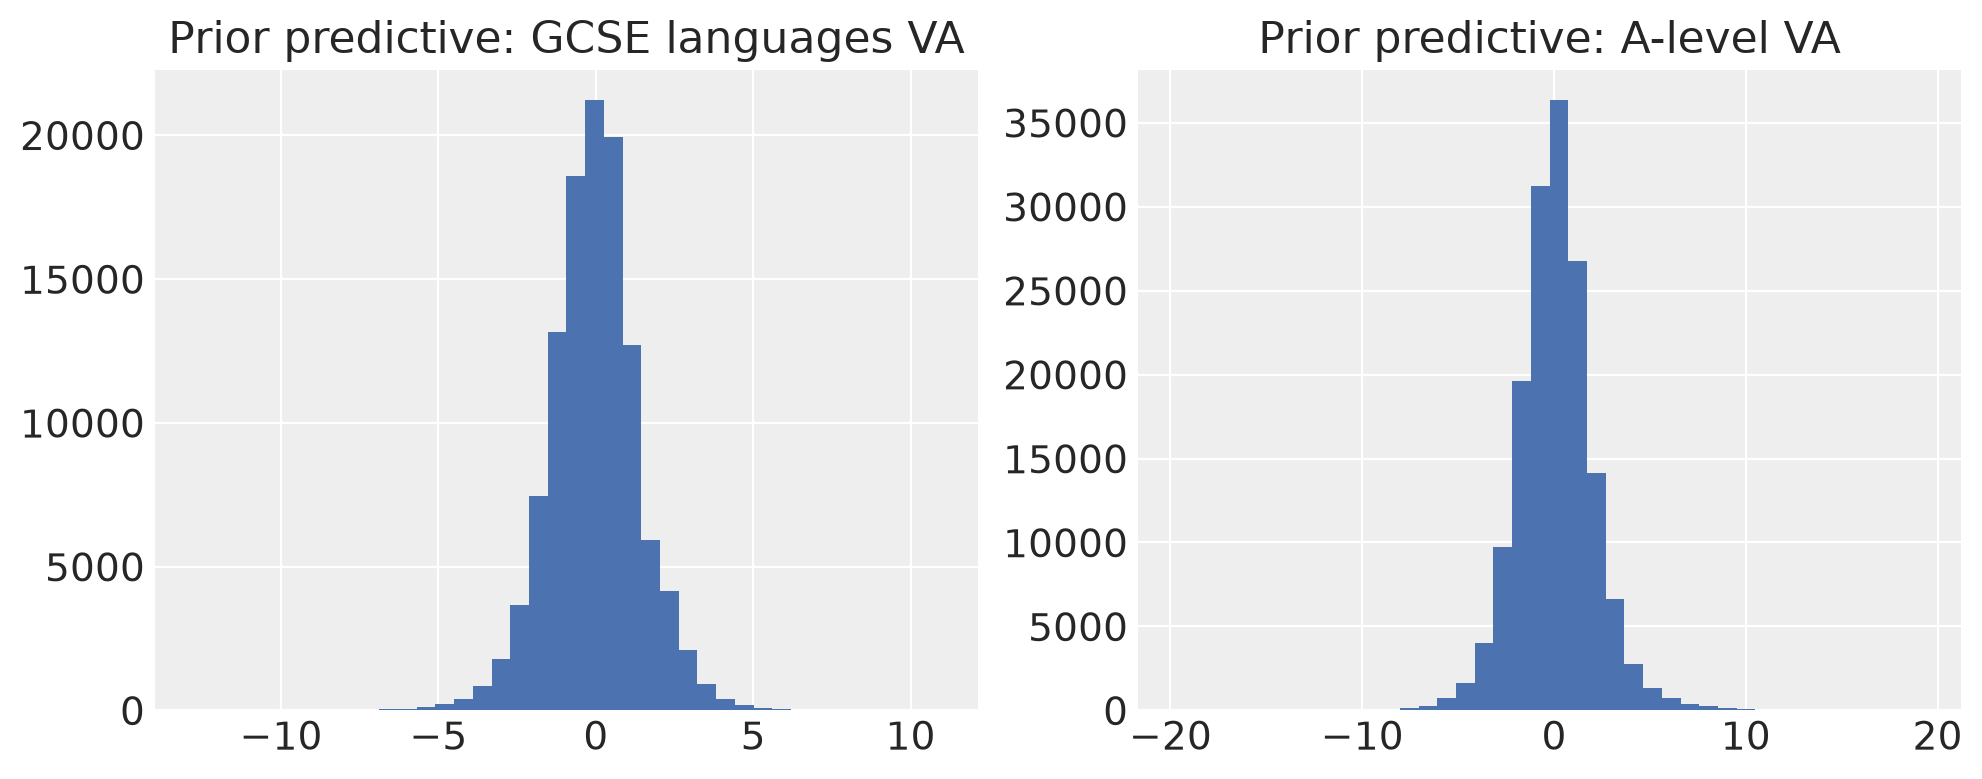

In [7]:
with corr_model:
    prior = pm.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(prior.prior_predictive["gcse_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[0].set_title("Prior predictive: GCSE languages VA")
axes[1].hist(prior.prior_predictive["alevel_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[1].set_title("Prior predictive: A-level VA")
plt.tight_layout()
plt.show()
del prior

### Fit

In [8]:
with corr_model:
    idata_corr = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                           random_seed=RANDOM_SEED, progressbar=False)
    idata_corr.update(pm.sample_posterior_predictive(idata_corr, random_seed=RANDOM_SEED, progressbar=False))

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, chol_cov, z]


Sampling: [alevel_obs, gcse_obs]


### Diagnostics

In [9]:
print(f"divergences = {int(idata_corr.sample_stats['diverging'].sum())}")
az.summary(idata_corr, var_names=["alpha", "beta", "chol_cov_stds", "chol_cov_corr", "mu_x", "tau_x"], round_to=3)

divergences = 0


/opt/conda/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/conda/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[Spanish],-0.277,0.041,-0.342,-0.210,1458.545,1909.972,1.001,0.001,0.001
alpha[French],-0.137,0.054,-0.223,-0.051,924.592,1541.501,1.005,0.002,0.001
alpha[German],-0.291,0.088,-0.429,-0.150,1629.489,2023.385,1.000,0.002,0.002
beta[Spanish],0.363,0.053,0.278,0.447,1269.682,1846.507,1.001,0.002,0.001
beta[French],0.160,0.065,0.058,0.264,937.296,1522.050,1.004,0.002,0.001
beta[German],0.306,0.112,0.129,0.479,1501.600,1967.668,1.001,0.003,0.002
chol_cov_stds[0],0.364,0.033,0.313,0.417,1579.996,2150.877,1.003,0.001,0.000
chol_cov_stds[1],0.387,0.036,0.331,0.446,1975.924,2747.277,1.001,0.001,0.000
chol_cov_stds[2],0.222,0.100,0.049,0.384,481.976,459.675,1.007,0.004,0.002
"chol_cov_corr[0, 0]",1.000,0.000,1.000,1.000,4000.000,4000.000,NaN,0.000,NaN


## What the pooling shows

### How related are a school's effects across the three languages?

Posterior of the three pairwise correlations between a school's true subject effects, after removing the GCSE effect.

Spanish-French     mean=0.520, 89% interval [0.225, 0.781]


Spanish-German     mean=0.249, 89% interval [-0.424, 0.783]
French-German     mean=0.155, 89% interval [-0.484, 0.728]


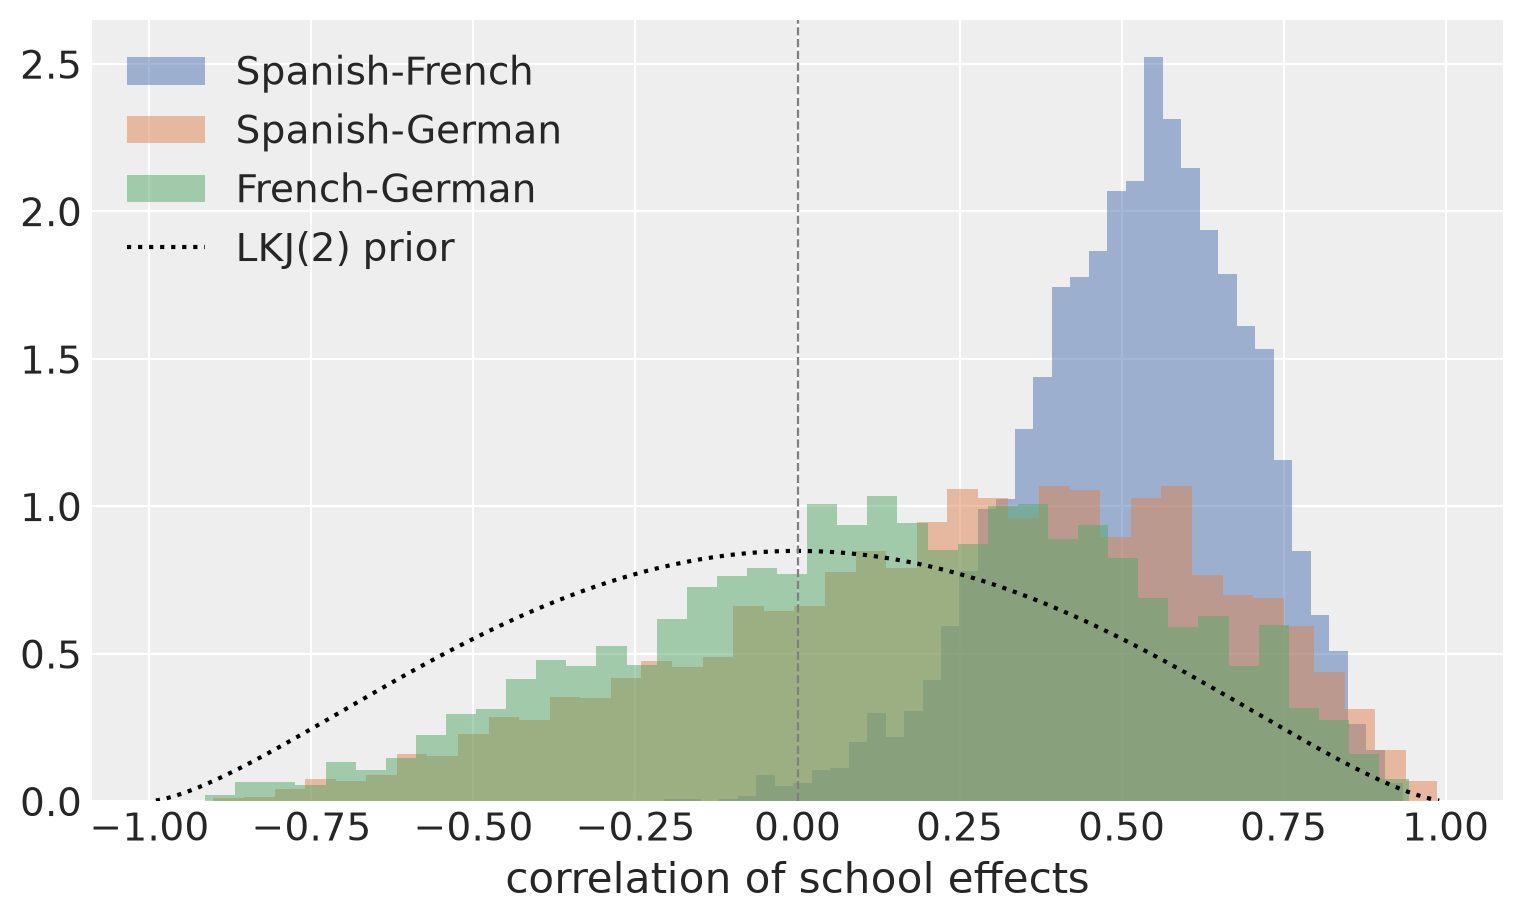

In [10]:
post = idata_corr.posterior
corr_s = post["chol_cov_corr"].to_numpy()

def summarise(x):
    lo, hi = np.percentile(x, [5.5, 94.5])
    return f"mean={x.mean():.3f}, 89% interval [{lo:.3f}, {hi:.3f}]"

pairs = [(0, 1), (0, 2), (1, 2)]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
pair_colors = ["#4C72B0", "#DD8452", "#55A868"]
for (i, j), c in zip(pairs, pair_colors):
    r = corr_s[..., i, j].ravel()
    ax.hist(r, bins=40, density=True, alpha=0.5, color=c, label=f"{subjects[i]}-{subjects[j]}")
    print(f"{subjects[i]}-{subjects[j]:10s} {summarise(r)}")
r_grid = np.linspace(-0.99, 0.99, 400)
prior_density = (1 - r_grid**2) ** 1.5
prior_density /= np.trapezoid(prior_density, r_grid)
ax.plot(r_grid, prior_density, color="black", linestyle=":", linewidth=1.5, label="LKJ(2) prior")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("correlation of school effects")
ax.legend()
plt.show()

### Slopes by subject

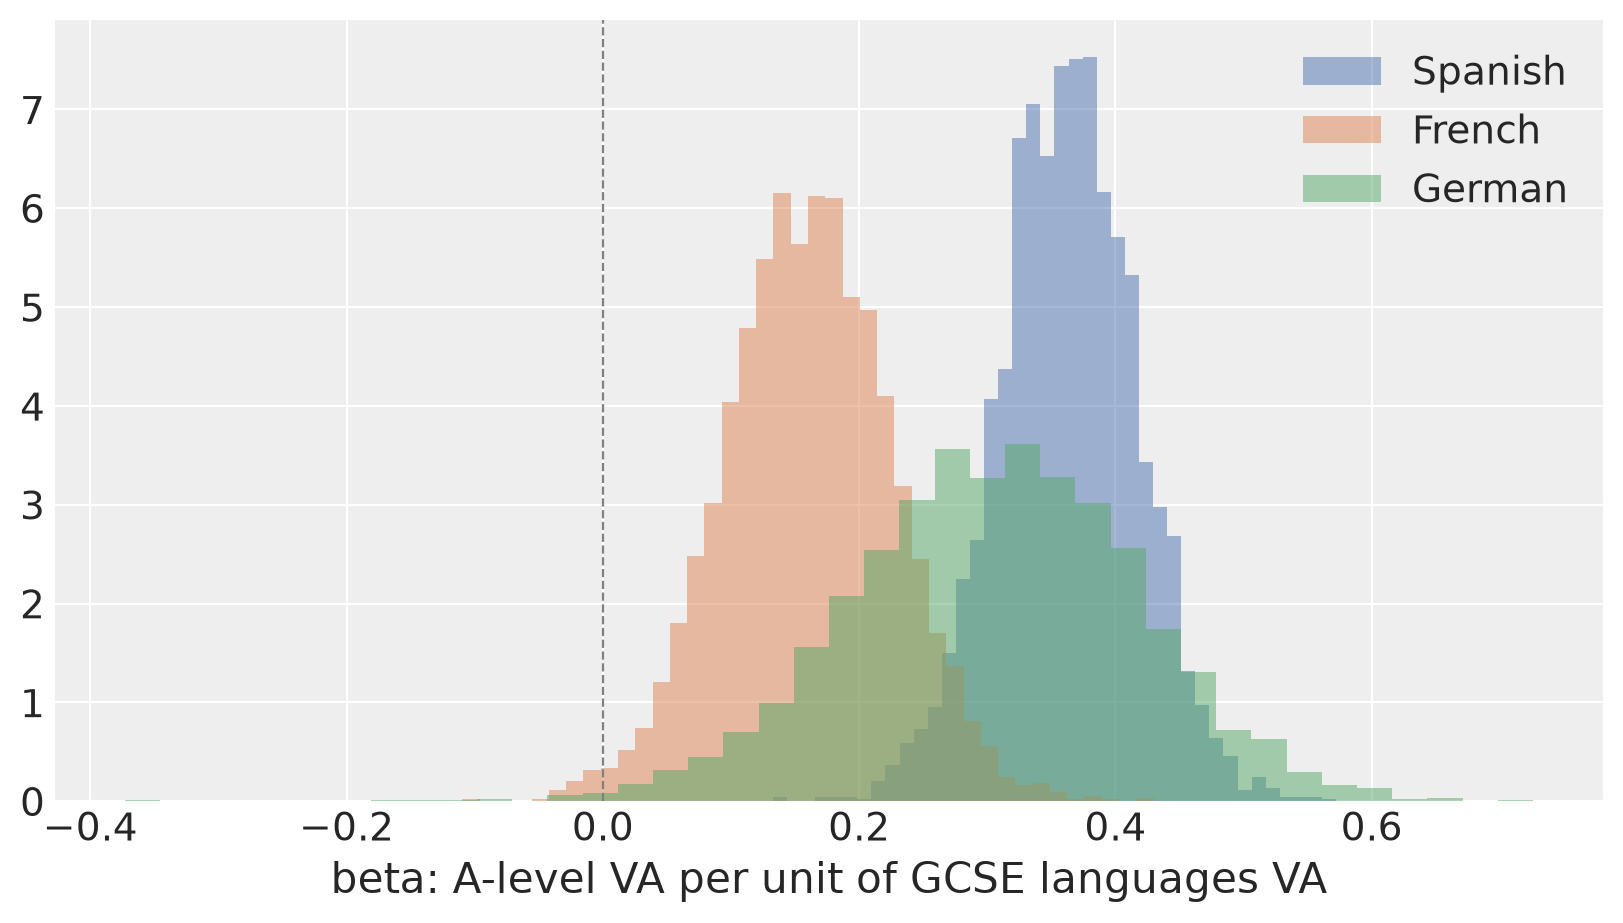

beta Spanish    mean=0.363, 89% interval [0.278, 0.447]
beta French     mean=0.160, 89% interval [0.058, 0.264]
beta German     mean=0.306, 89% interval [0.129, 0.479]


In [11]:
beta_post = post["beta"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for subject in subjects:
    ax.hist(beta_post.sel(subject=subject).to_numpy().ravel(), bins=40, density=True, alpha=0.5,
            color=colors[subject], label=subject)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("beta: A-level VA per unit of GCSE languages VA")
ax.legend()
plt.show()

for subject in subjects:
    print(f"beta {subject:10s}", summarise(beta_post.sel(subject=subject).to_numpy().ravel()))

## Goodness of fit

Bayesian $R^2$ on the latent scale, per subject: the variance of the structural part $\alpha_s + \beta_s x_i$ relative to that variance plus the residual variance $\tau_s^2$.

In [12]:
x_post = post["mu_x"].to_numpy()[..., None] + post["tau_x"].to_numpy()[..., None] * post["x_raw"].to_numpy()
stds_post = post["chol_cov_stds"].to_numpy()
r2 = {}
for k, name in enumerate(subjects):
    sch = s_idx[subj_idx == k]
    fit = post["alpha"].sel(subject=name).to_numpy()[..., None] + post["beta"].sel(subject=name).to_numpy()[..., None] * x_post[..., sch]
    var_fit = fit.var(axis=-1)
    r2[name] = (var_fit / (var_fit + stds_post[..., k] ** 2)).ravel()
    print(f"{name}: R² from GCSE languages VA: {summarise(r2[name])}")

Spanish: R² from GCSE languages VA: mean=0.275, 89% interval [0.169, 0.383]
French: R² from GCSE languages VA: mean=0.066, 89% interval [0.008, 0.148]
German: R² from GCSE languages VA: mean=0.440, 89% interval [0.068, 0.927]


### Residual vs. GCSE value-added

Standardised residuals, binned over GCSE languages VA, for each subject (6 bins, as the samples are small). Flat near zero means the linear relationship is adequate.

/tmp/ipykernel_102965/761980998.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


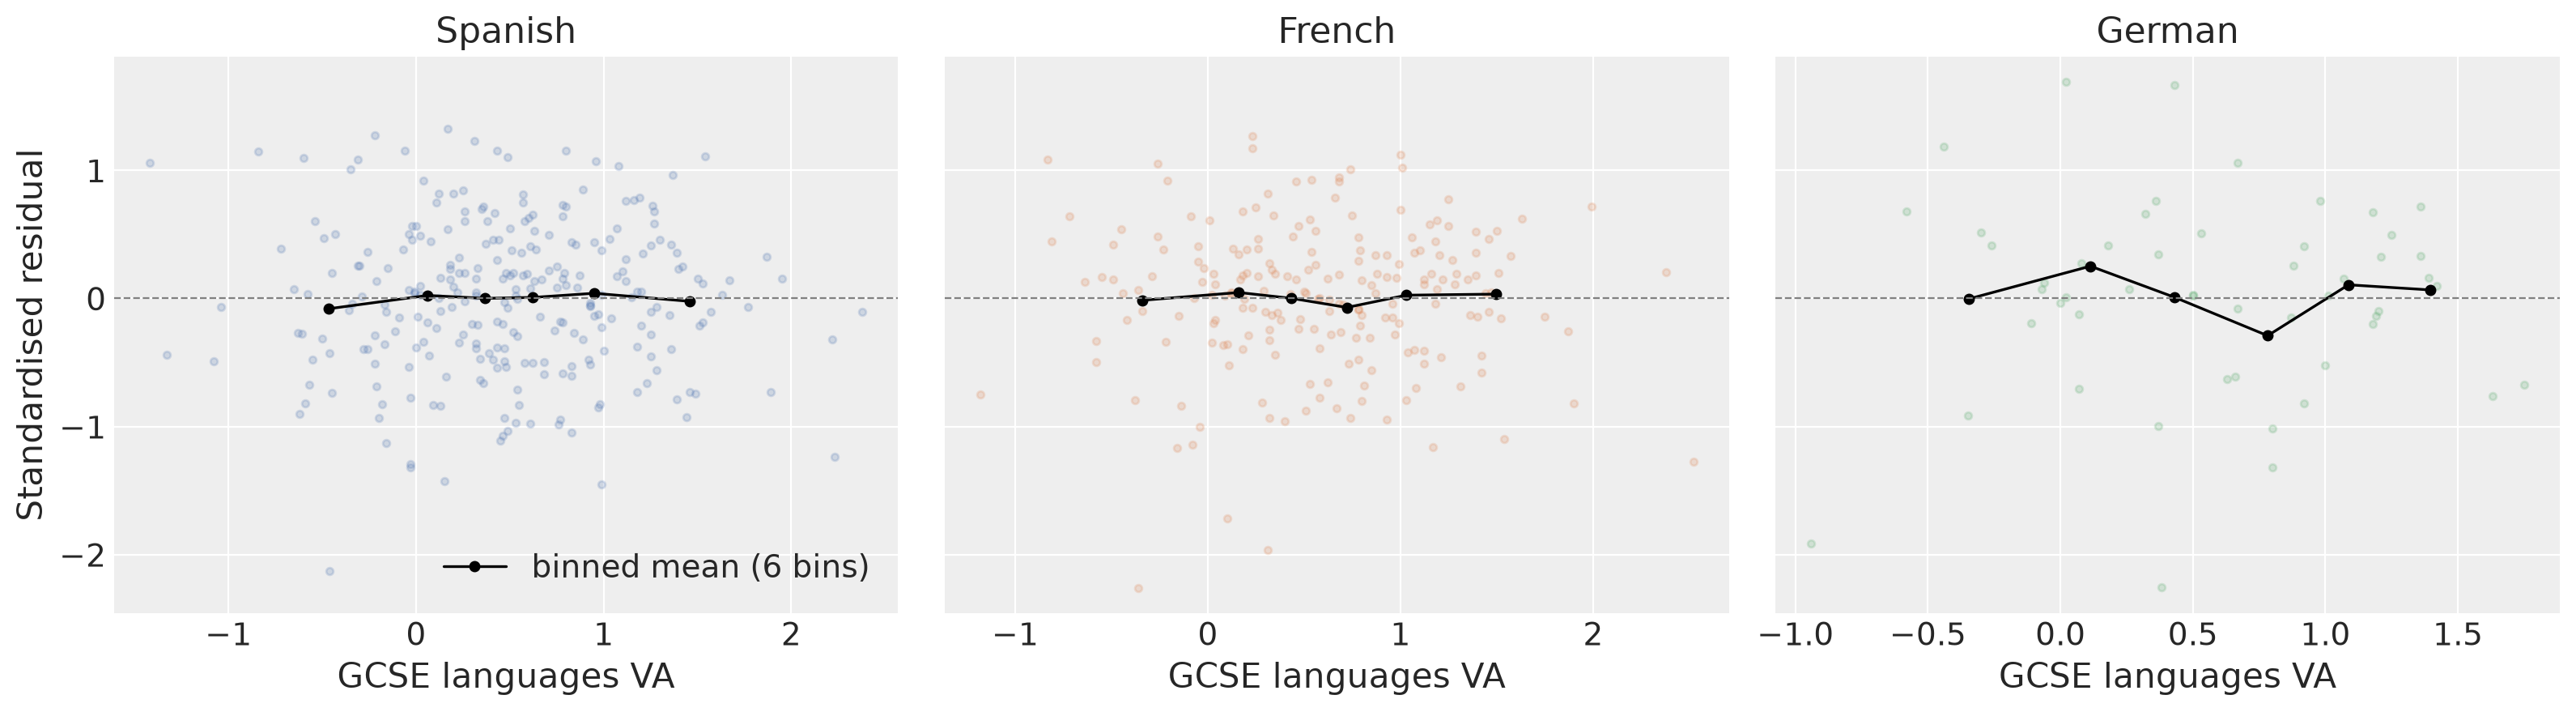

In [13]:
n_obs = len(long)
pred = idata_corr.posterior_predictive["alevel_obs"].to_numpy().reshape(-1, n_obs)
long["std_resid"] = (y_obs - pred.mean(axis=0)) / pred.std(axis=0)
long = long.merge(schools[["URN", "gcse_va"]], on="URN", how="left")
del pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, subject in zip(axes, subjects):
    g = long[long["subject"] == subject]
    binned = g.groupby(pd.qcut(g["gcse_va"], 6), observed=True).agg(gcse_va=("gcse_va", "mean"), r=("std_resid", "mean"))
    ax.scatter(g["gcse_va"], g["std_resid"], color=colors[subject], alpha=0.2, s=10)
    ax.plot(binned["gcse_va"], binned["r"], color="black", marker="o", markersize=4, linewidth=1.2, label="binned mean (6 bins)")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(subject)
    ax.set_xlabel("GCSE languages VA")
axes[0].set_ylabel("Standardised residual")
axes[0].legend()
plt.tight_layout()
plt.show()

### Do the strongest GCSE schools "top out"?

Mean A-level VA by GCSE languages VA tercile, for each subject (terciles, as the samples are small).

subject,Spanish,French,German
gcse_tercile,,,
1,-0.352,-0.107,-0.237
2,-0.086,-0.071,-0.202
3,0.154,0.094,0.138


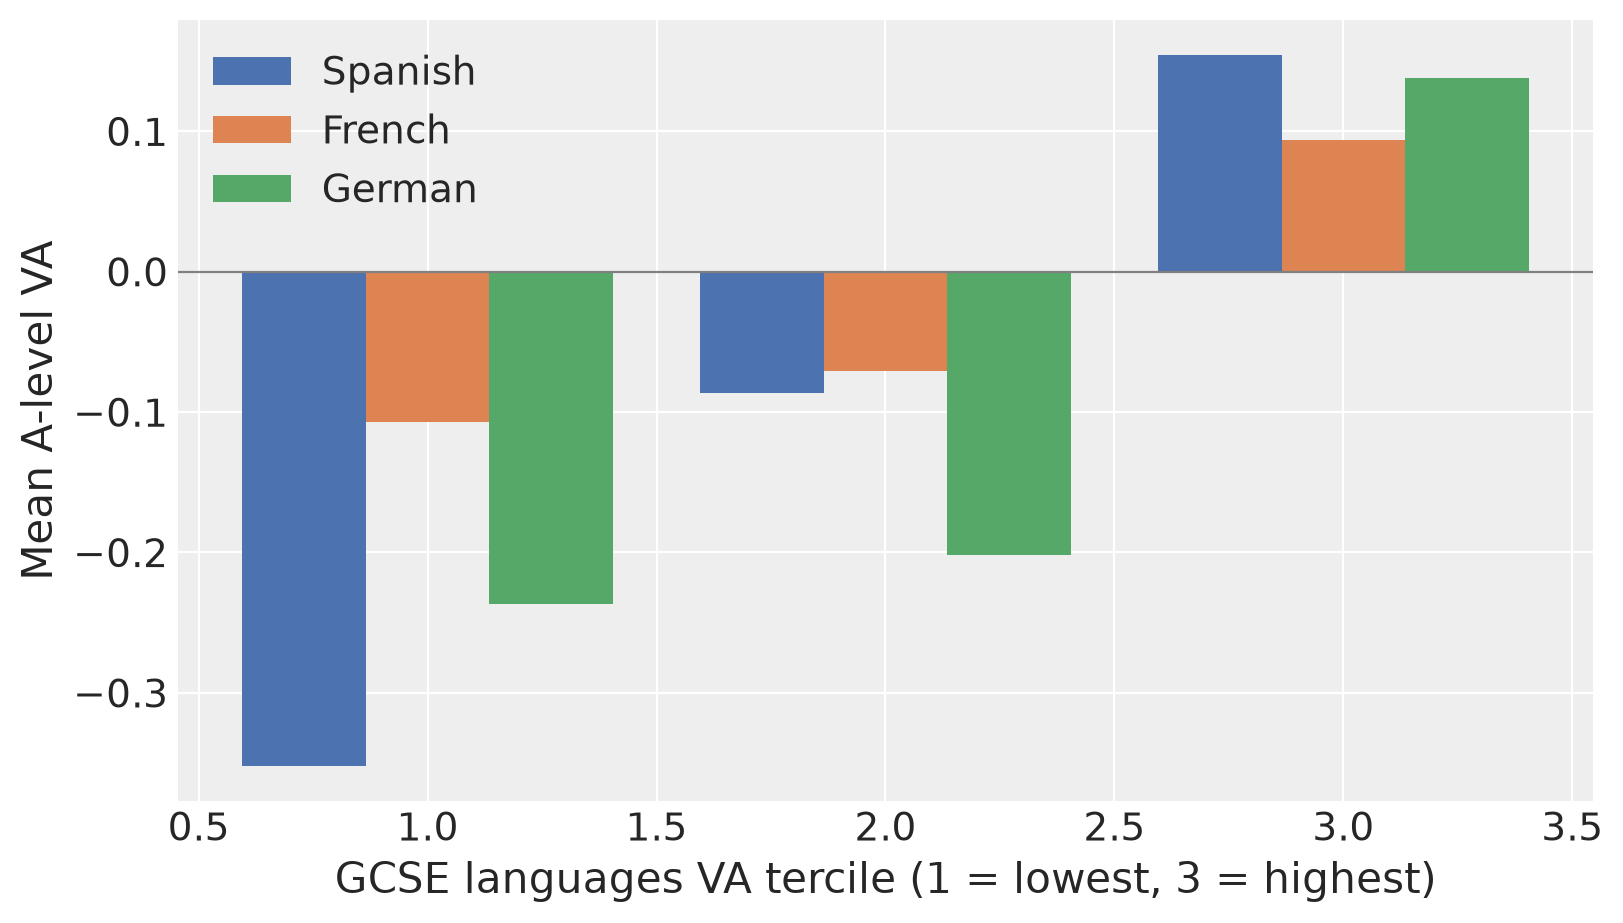

In [14]:
quint = []
for subject, g in long.groupby("subject"):
    t = g.groupby(pd.qcut(g["gcse_va"], 3, labels=range(1, 4)), observed=True).agg(
        mean_alevel_va=("alevel_va", "mean"), n=("URN", "count"))
    t["subject"] = subject
    quint.append(t)
tercile_table = pd.concat(quint).reset_index().rename(columns={"gcse_va": "gcse_tercile"})
display(tercile_table.pivot(index="gcse_tercile", columns="subject", values="mean_alevel_va")[subjects].round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.27
for k, subject in enumerate(subjects):
    t = tercile_table[tercile_table["subject"] == subject]
    ax.bar(t["gcse_tercile"].astype(int) + (k - 1) * width, t["mean_alevel_va"], width, color=colors[subject], label=subject)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("GCSE languages VA tercile (1 = lowest, 3 = highest)")
ax.set_ylabel("Mean A-level VA")
ax.legend()
plt.show()

### Is the shared-school-effect model worth attempting?

In the science notebook the correlated-residuals model showed strong correlations and most schools had all three subjects, so a one-factor shared-effect model was worth trying. Here we check how much the data actually taught us about each correlation, compared with the LKJ(2) prior, before deciding.

In [15]:
r_grid = np.linspace(-0.9999, 0.9999, 20001)
prior_cdf = np.cumsum((1 - r_grid**2) ** 1.5)
prior_cdf /= prior_cdf[-1]
prior_lo, prior_hi = r_grid[np.searchsorted(prior_cdf, 0.055)], r_grid[np.searchsorted(prior_cdf, 0.945)]
print(f"LKJ(2) prior, 89% interval for each correlation: [{prior_lo:.2f}, {prior_hi:.2f}] (width {prior_hi - prior_lo:.2f})")

rows = []
for (i, j) in pairs:
    r = corr_s[..., i, j].ravel()
    lo, hi = np.percentile(r, [5.5, 94.5])
    rows.append({
        "pair": f"{subjects[i]}-{subjects[j]}",
        "schools_with_both": int(overlap.iloc[i, j]),
        "posterior_width": round(hi - lo, 2),
        "share_of_prior_width": round((hi - lo) / (prior_hi - prior_lo), 2),
    })
pd.DataFrame(rows)

LKJ(2) prior, 89% interval for each correlation: [-0.66, 0.66] (width 1.31)


,pair,schools_with_both,posterior_width,share_of_prior_width
0,Spanish-French,107,0.56,0.42
1,Spanish-German,25,1.21,0.92
2,French-German,28,1.21,0.92


Only the Spanish-French correlation is much narrower than the prior. The two German correlations are about as wide as the prior, so the data has told us almost nothing about them. A one-factor model would need to estimate a German loading from those same 25 and 28 schools, plus only 16 schools that have all three subjects, and would just reproduce that uncertainty in a more constrained form. We therefore **do not fit the shared-school-effect model** for languages.

## Interpretation

- **The three languages respond to GCSE languages VA, but not equally, and the data are thin.** The Spanish slope is 0.36 (89% interval 0.27–0.45), higher than in the sciences, Maths or English. French is 0.16 (0.05–0.26), and German 0.32 (0.14–0.49) but based on only 52 schools. GCSE languages VA explains about 27% of the variance in true A-level Spanish VA, only about 6% for French, and an essentially undetermined amount for German (0.07–0.93). The Spanish result is the most reliable (267 schools).
- **Schools' Spanish and French effects are positively correlated (about 0.50, 89% interval 0.21–0.76).** A school doing unusually well in A-level Spanish, given its GCSE languages VA, tends to do well in French. This is the only correlation the data pins down; it is weaker than Chemistry-Biology (0.84) in the sciences and stronger than English Language-Literature (0.19).
- **The German correlations are not learned from the data.** Spanish-German (0.29, interval -0.37 to 0.80) and French-German (0.19, -0.45 to 0.74) are about as wide as the LKJ(2) prior (-0.66 to 0.66), because only 25 and 28 schools have each pair. The point estimates should not be interpreted.
- **No sign of nonlinearity or topping out, as far as one can tell.** The binned residuals for Spanish and French stay near zero across the range, and mean A-level VA rises across GCSE terciles in all three subjects (Spanish -0.35 to +0.15, French -0.11 to +0.09, German -0.24 to +0.14). The German residual plot is too sparse to say much.
- **Why this dataset is harder.** Few schools offer A-level languages (380 schools with any of the three), cohorts are tiny (median 7–8 entries, so each A-level VA has a standard error of about 0.37), and only 16 schools have all three subjects. The measurement model accounts for the noise, but the posteriors are correspondingly wide.
- **Decision on the pooled model.** We did not fit the shared-school-effect model, because the data do not identify the German correlations that such a model would depend on (see above). If more years of data or more schools became available, it would be worth revisiting.
- **Caveats.** Single year of data; PSIS-LOO is not usable for these latent-variable models. The GCSE languages measure is based on the pupils entered for languages, a smaller and more selected group than the whole cohort. Sampling was clean (0 divergences, r_hat ≤ 1.011).

## Regional effects

Does the relationship between GCSE languages VA and A-level VA differ by region? We extend the correlated-residuals model so that each subject's intercept and slope vary by region (the 9 English regions, `RGN24NM`), with partial pooling:

$$
\alpha_{sr} = \alpha_s + \sigma_\alpha\, a_{sr}, \qquad \beta_{sr} = \beta_s + \sigma_\beta\, b_{sr}, \qquad a_{sr}, b_{sr} \sim \text{Normal}(0, 1)
$$

The spreads $\sigma_\alpha$ and $\sigma_\beta$ are shared across subjects (with only 9 regions there is little information for separate ones), so the model estimates one typical size of regional difference in baseline A-level VA and one in the slope, while letting each subject's regional pattern differ. Both get a tight `HalfNormal(0.5)` prior. Everything else, including the LKJ correlation of school residuals across subjects, is unchanged.

First, the raw picture: mean GCSE and A-level VA by region and the number of schools.

In [16]:
region_of_school = schools["URN"].map(raw.set_index("URN")["RGN24NM"])
region_idx, region_labels = pd.factorize(region_of_school)
n_regions = len(region_labels)
r_idx = region_idx[s_idx]

raw_by_region = pd.DataFrame({"schools": region_of_school.value_counts(), "mean GCSE VA": schools.groupby(region_of_school)["gcse_va"].mean()})
for subject in subjects:
    g = long[long["subject"] == subject]
    raw_by_region[f"mean A-level {subject} VA"] = g.groupby(g["URN"].map(raw.set_index("URN")["RGN24NM"]))["alevel_va"].mean()
raw_by_region.round(3).sort_values("schools", ascending=False)

,schools,mean GCSE VA,mean A-level Spanish VA,mean A-level French VA,mean A-level German VA
URN,,,,,
London,92,0.740,0.073,0.146,0.059
South East,74,0.528,-0.099,-0.066,-0.095
East of England,48,0.399,0.002,-0.081,0.084
South West,41,0.473,-0.156,-0.024,-0.005
North West,36,0.375,-0.137,0.012,-0.413
East Midlands,27,0.198,-0.550,-0.180,-0.350
Yorkshire and The Humber,26,0.373,-0.220,-0.177,-0.273
West Midlands,25,0.329,-0.240,-0.079,0.500
North East,11,0.081,-0.326,-0.049,-0.547


In [17]:
with pm.Model(coords={"subject": subjects, "region": region_labels}) as region_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")
    sigma_alpha = pm.HalfNormal("sigma_alpha", 0.5)
    sigma_beta = pm.HalfNormal("sigma_beta", 0.5)
    a_raw = pm.Normal("a_raw", 0, 1, dims=("subject", "region"))
    b_raw = pm.Normal("b_raw", 0, 1, dims=("subject", "region"))
    alpha_sr = pm.Deterministic("alpha_sr", alpha[:, None] + sigma_alpha * a_raw, dims=("subject", "region"))
    beta_sr = pm.Deterministic("beta_sr", beta[:, None] + sigma_beta * b_raw, dims=("subject", "region"))

    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov", n=n_subjects, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0, shape=n_subjects), compute_corr=True
    )
    z = pm.Normal("z", 0, 1, shape=(n_schools, n_subjects))
    eps = pt.dot(z, chol.T)[s_idx, subj_idx]

    y_true = alpha_sr[subj_idx, r_idx] + beta_sr[subj_idx, r_idx] * x_true[s_idx] + eps

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=y_se, observed=y_obs)

with region_model:
    idata_region = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                             random_seed=RANDOM_SEED, progressbar=False)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, sigma_alpha, sigma_beta, a_raw, b_raw, chol_cov, z]


In [18]:
print(f"divergences = {int(idata_region.sample_stats['diverging'].sum())}")
az.summary(idata_region, var_names=["sigma_alpha", "sigma_beta", "alpha", "beta", "chol_cov_stds", "mu_x", "tau_x"], round_to=3)

divergences = 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_alpha,0.049,0.034,0.004,0.110,535.236,512.480,1.002,0.001,0.001
sigma_beta,0.048,0.040,0.004,0.125,559.789,719.008,1.003,0.002,0.001
alpha[Spanish],-0.284,0.046,-0.357,-0.211,1304.843,1821.837,1.001,0.001,0.001
alpha[French],-0.138,0.057,-0.227,-0.048,1097.706,1441.683,1.001,0.002,0.001
alpha[German],-0.293,0.090,-0.435,-0.146,1845.160,2209.294,1.001,0.002,0.001
beta[Spanish],0.358,0.061,0.260,0.453,1082.211,1603.171,1.005,0.002,0.001
beta[French],0.149,0.070,0.036,0.264,935.050,1205.799,1.002,0.002,0.001
beta[German],0.313,0.112,0.137,0.489,1664.538,2160.144,1.000,0.003,0.002
chol_cov_stds[0],0.361,0.033,0.309,0.414,1700.027,1918.307,1.001,0.001,0.000
chol_cov_stds[1],0.385,0.037,0.327,0.445,1662.238,2420.738,1.002,0.001,0.001


### How big are the regional differences?

The posteriors of the two spreads: `sigma_alpha` (typical regional shift in baseline A-level VA) and `sigma_beta` (typical regional difference in the slope). A spread near zero means regions look alike.

sigma_alpha: mean=0.049, 89% interval [0.004, 0.110]
sigma_beta: mean=0.048, 89% interval [0.004, 0.125]


/tmp/ipykernel_102965/2655007468.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


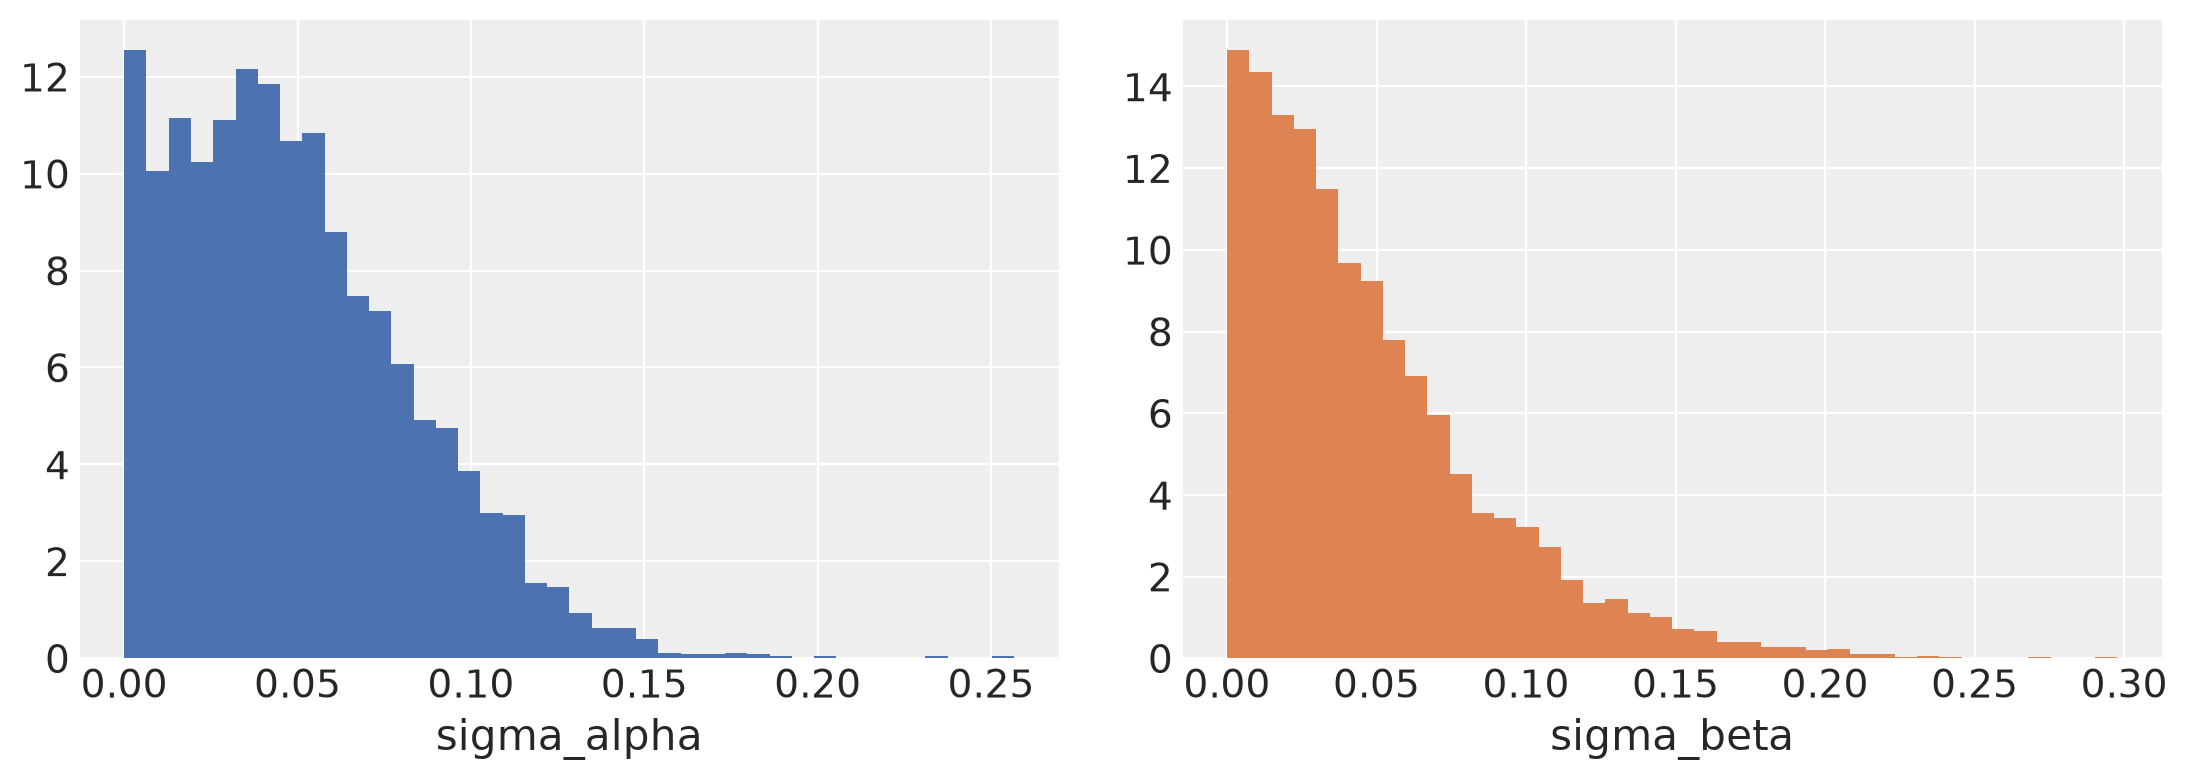

In [19]:
pr = idata_region.posterior
for name in ["sigma_alpha", "sigma_beta"]:
    print(f"{name}: {summarise(pr[name].to_numpy().ravel())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, c in zip(axes, ["sigma_alpha", "sigma_beta"], ["#4C72B0", "#DD8452"]):
    ax.hist(pr[name].to_numpy().ravel(), bins=40, density=True, color=c)
    ax.set_xlabel(name)
plt.tight_layout()
plt.show()

### Region by region

For each subject, each region's intercept and slope relative to that subject's average across regions (median and 89% interval). Regions are ordered by number of schools, largest at the top. Intervals that straddle zero mean the region is not distinguishable from the subject's average.

/tmp/ipykernel_102965/2102355965.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


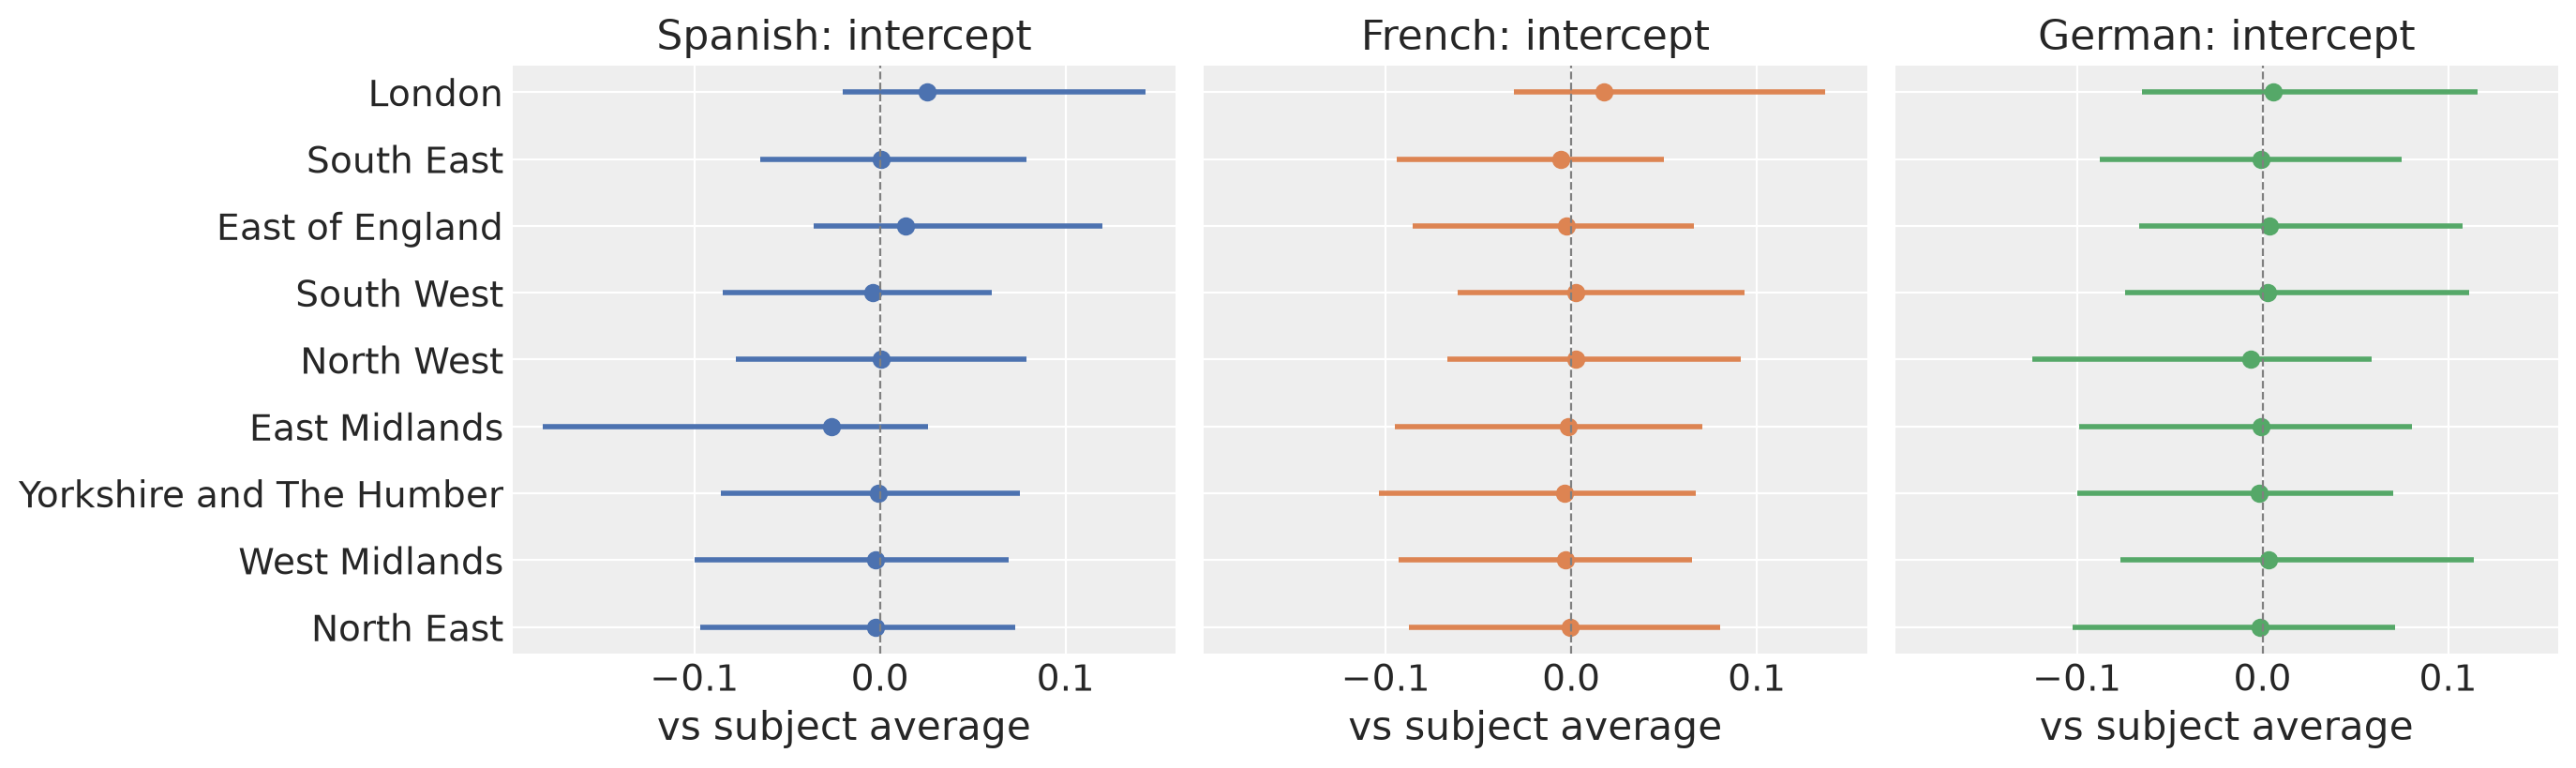

/tmp/ipykernel_102965/2102355965.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


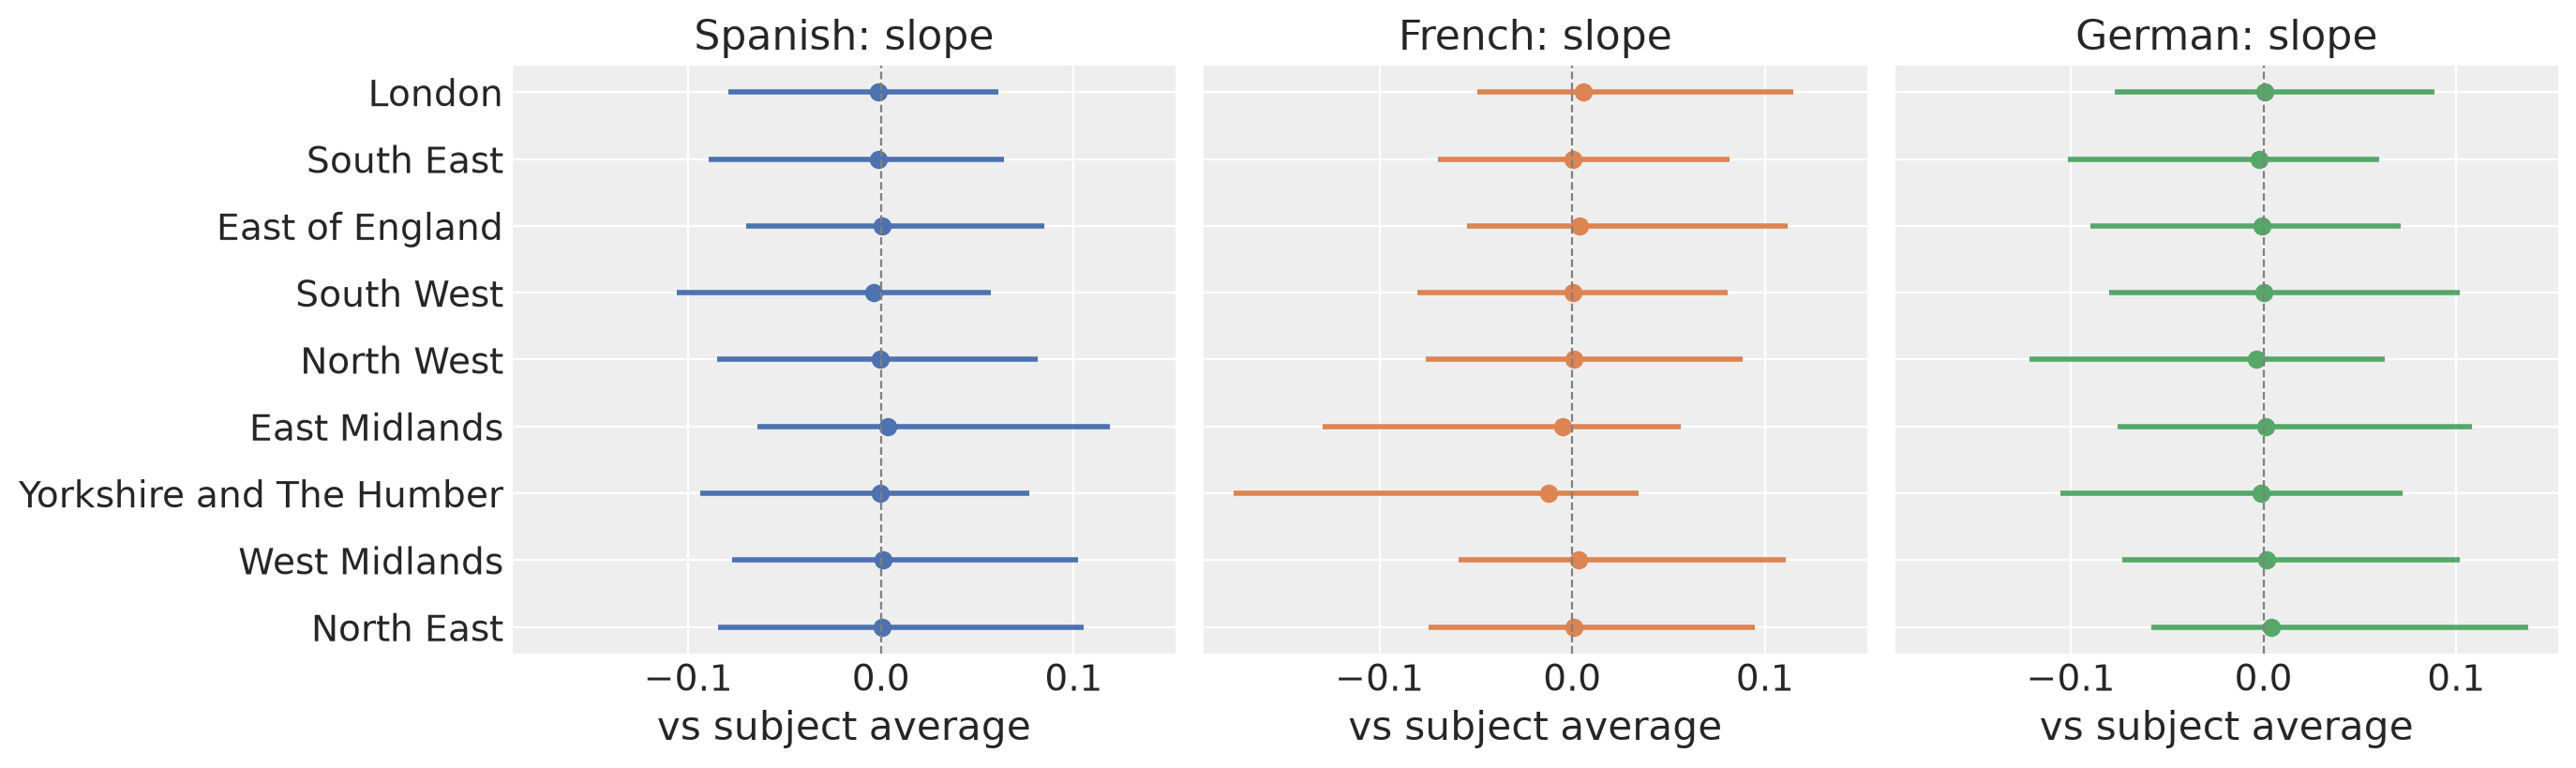

In [20]:
region_order = list(raw_by_region.sort_values("schools", ascending=False).index)
ord_idx = [list(region_labels).index(r) for r in region_order]

def region_deviation_plot(var, base, title):
    dev = (pr[var] - pr[base]).transpose("chain", "draw", "subject", "region").to_numpy()
    fig, axes = plt.subplots(1, n_subjects, figsize=(4.6 * n_subjects, 4.2), sharey=True, sharex=True)
    for k, (ax, subject) in enumerate(zip(np.atleast_1d(axes), subjects)):
        d = dev[:, :, k, :].reshape(-1, n_regions)[:, ord_idx]
        lo, med, hi = np.percentile(d, [5.5, 50, 94.5], axis=0)
        y = np.arange(n_regions)[::-1]
        ax.hlines(y, lo, hi, color=colors[subject], linewidth=2)
        ax.plot(med, y, "o", color=colors[subject])
        ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_title(f"{subject}: {title}")
        ax.set_yticks(y, region_order)
        ax.set_xlabel("vs subject average")
    plt.tight_layout()
    plt.show()

region_deviation_plot("alpha_sr", "alpha", "intercept")
region_deviation_plot("beta_sr", "beta", "slope")

### Does region change the picture?

The subject-level slopes (now the average across regions) and Bayesian $R^2$ with and without regional terms, and the cross-subject correlations.

In [21]:
xr = pr["mu_x"].to_numpy()[..., None] + pr["tau_x"].to_numpy()[..., None] * pr["x_raw"].to_numpy()
a_sr = pr["alpha_sr"].transpose("chain", "draw", "subject", "region").to_numpy()
b_sr = pr["beta_sr"].transpose("chain", "draw", "subject", "region").to_numpy()
stds_r = pr["chol_cov_stds"].to_numpy()
for k, s in enumerate(subjects):
    m = subj_idx == k
    sch, reg = s_idx[m], r_idx[m]
    fit = a_sr[:, :, k, :][..., reg] + b_sr[:, :, k, :][..., reg] * xr[..., sch]
    var_fit = fit.var(axis=-1)
    r2_region = (var_fit / (var_fit + stds_r[..., k] ** 2)).ravel()
    print(f"{s}:")
    print(f"   slope   without region: {summarise(post['beta'].sel(subject=s).to_numpy().ravel())}")
    print(f"   slope   mean over regions: {summarise(pr['beta'].sel(subject=s).to_numpy().ravel())}")
    print(f"   R² without region: {summarise(r2[s])}")
    print(f"   R² with region:    {summarise(r2_region)}")

corr_r = pr["chol_cov_corr"].to_numpy()
print()
for i, j in pairs:
    print(f"corr {subjects[i]}-{subjects[j]}: without region {summarise(corr_s[..., i, j].ravel())}   with region {summarise(corr_r[..., i, j].ravel())}")

Spanish:
   slope   without region: mean=0.363, 89% interval [0.278, 0.447]
   slope   mean over regions: mean=0.358, 89% interval [0.260, 0.453]
   R² without region: mean=0.275, 89% interval [0.169, 0.383]
   R² with region:    mean=0.292, 89% interval [0.182, 0.409]
French:
   slope   without region: mean=0.160, 89% interval [0.058, 0.264]
   slope   mean over regions: mean=0.149, 89% interval [0.036, 0.264]
   R² without region: mean=0.066, 89% interval [0.008, 0.148]
   R² with region:    mean=0.088, 89% interval [0.022, 0.177]
German:
   slope   without region: mean=0.306, 89% interval [0.129, 0.479]
   slope   mean over regions: mean=0.313, 89% interval [0.137, 0.489]
   R² without region: mean=0.440, 89% interval [0.068, 0.927]
   R² with region:    mean=0.493, 89% interval [0.116, 0.985]

corr Spanish-French: without region mean=0.520, 89% interval [0.225, 0.781]   with region mean=0.512, 89% interval [0.204, 0.774]
corr Spanish-German: without region mean=0.249, 89% interval 

## Interpretation of the regional effects

- **We find no reliable regional effect for languages.** The typical regional shift in baseline A-level VA (`sigma_alpha`) is about 0.05 (89% interval 0.004–0.11) and in the slope (`sigma_beta`) about 0.05 (0.004–0.125). Both intervals reach almost to zero, and in the region-by-region plots every interval for every subject straddles zero, for both intercepts and slopes. With 380 schools spread over 9 regions (only 11 in the North East and 25–27 in three others) and tiny cohorts, the data can rule out only large regional differences.
- **The raw regional pattern is a GCSE pattern.** London has the highest mean GCSE languages VA (0.74) and the highest A-level Spanish and French VA, while the North East and East Midlands have the lowest GCSE VA. For example, East Midlands Spanish has a low raw A-level VA (-0.55) but also a low GCSE languages VA (0.20). Given GCSE VA, the regional deviations are small and uncertain (largest are London Spanish about +0.03 and East Midlands Spanish about -0.03, both within the noise).
- **Nothing else moves.** The subject slopes (Spanish 0.36, French 0.15, German 0.31) and the Spanish-French correlation (about 0.51) are unchanged by adding region, and the German correlations remain as poorly determined as before. R² rises slightly (Spanish 0.28 to 0.29, French 0.07 to 0.09, German 0.44 to 0.49, the last still very uncertain).
- **Caveats.** The regional spreads are shared across subjects and estimated from very few schools per region, so they are strongly regularised toward zero by the prior; a small true regional effect could be hidden. Sampling was clean (0 divergences, r_hat ≤ 1.02).